In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [3]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/6.neGLM")

In [4]:
from GridMaze.analysis.neGLM import load_model_sets as lms
from GridMaze.analysis.neGLM import model_comparisons as mc

reload(lms)
reload(mc)

<module 'GridMaze.analysis.neGLM.model_comparisons' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/model_comparisons.py'>

baseline vs embedding:
                      feature_group model_type     t_stat     p_val  \
0                   place_direction  baseline2   7.985724  0.000497   
1                   place_direction   baseline  11.806885  0.000077   
2  place_direction_distance_to_goal  baseline2   8.241120  0.000429   
3  place_direction_distance_to_goal   baseline  11.308994  0.000095   
4                             place   baseline   6.054119  0.001773   

   p_val_corr  
0    0.000621  
1    0.000236  
2    0.000621  
3    0.000236  
4    0.001773  


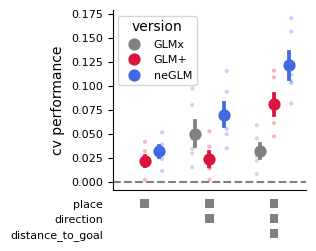

In [5]:
reload(mc)
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, axes = plt.subplots(2, 1, sharex=True, figsize=(2.5, 3), gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05})
mc.plot_performance_validation(nbe_validation, plot_single_subjects=True, axes=axes)
f.savefig(FIG_SAVE_PATH / "performance_validation.pdf")

place_direction_factorised vs place_direction_nonlinear
t_stat: -5.306830646355353, p_val: 0.003174222287973421
place_direction_distance_to_goal_factorised vs place_direction_distance_to_goal_nonlinear
t_stat: 1.4179475992257404, p_val: 0.2154064267641584


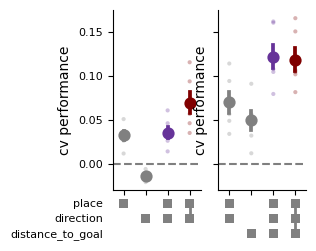

In [8]:
reload(mc)
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

f, axes = plt.subplots(
    2,
    2,
    figsize=(2.5, 3),
    sharey="row",
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05},
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_factorised", "place_direction_nonlinear"],
    plot_single_subjects=True,
    colors=["grey", "grey", "rebeccapurple", "maroon"],
    axes=axes[:, 0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_factorised",
        "place_direction_distance_to_goal_nonlinear",
    ],
    plot_single_subjects=True,
    colors=["grey", "grey", "rebeccapurple", "maroon"],
    axes=axes[:, 1],
)
f.savefig(FIG_SAVE_PATH / "interaction_validation.pdf")

In [6]:
from GridMaze.analysis.neGLM import variance_explained as ve
from GridMaze.analysis.neGLM import variance_explained_null as nul

reload(ve)

<module 'GridMaze.analysis.neGLM.variance_explained' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/variance_explained.py'>

In [ ]:
reload(ve)
late_sessions = False
model_set_name = "variance_explained" if late_sessions else "variance_explained_all_sessions"
variance_explained_results = lms.load_model_set_cv_scores(
    model_set_name, maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
]

cpd_df = nul.get_cpd_df(variance_explained_results, r2_thres=0.075)
feature_tuned_df = nul.get_feature_tuned_df(variance_explained_results, r2_thres=0.075, alpha=0.01)


models = [f.split("_", 1)[-1] for f in reduced_models]

            feature    t_stat     p_val  p_val_corr
0  distance_to_goal  6.106832  0.000853    0.000853
1   place_direction  8.762988  0.000160    0.000321


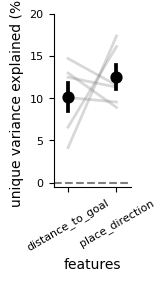

In [10]:
reload(nul)
f, ax = plt.subplots(figsize=(1, 3 * (3 / 4)))
nul.plot_variance_explained(
    cpd_df,
    plot_single_subject=True,
    marker_color=["black", "black"],
    print_stats=True,
    ax=ax,
)
ax.set_ylim(-0.5, 20)
f.savefig(FIG_SAVE_PATH / "variance_explained_cpd.pdf")

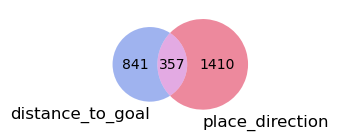

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
nul.plot_feature_venn(
    feature_tuned_df,
    colors=("royalblue", "crimson"),
    ax=ax,
)
fig.savefig(FIG_SAVE_PATH / "venn_diagram.pdf")

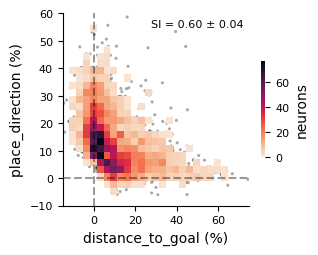

In [43]:
reload(nul)
cpd2d_kwargs = dict(cmap="rocket_r", xlims=(-15, 75), ylims=(-10, 60))
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(cpd_df, **cpd2d_kwargs, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist.pdf")

### compare to null with full mixed selectivity

In [16]:
reload(lms)
reload(nul)
ridge_df, perm_df = nul.load_null_data()

In [ ]:
ridge_cpd_df = nul.get_cpd_df(ridge_df)
perm_cpd_df = nul.get_cpd_df(perm_df[perm_df.permutation == 0])

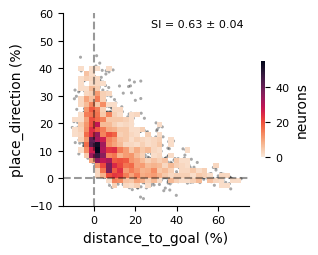

In [44]:
# confirm ridge from latents works ok (similar to Poisson above)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(ridge_cpd_df, **cpd2d_kwargs, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist_ridge.pdf")

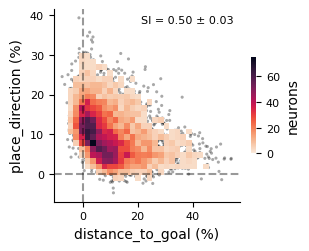

In [45]:
# plot example permutation (where neurons have been randomly rotated such that reps must be mixed across neurons)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
nul.plot_cpd_2d(perm_cpd_df, cmap="rocket_r", vmax=75, ax=ax)
f.savefig(FIG_SAVE_PATH / "cpd_2d_hist_permutation.pdf")

metric: mean_selectivity  (random-effects: n_subjects=6)
  null mean: 0.5027  std: 0.0039  n_perms: 1000
  Poisson: 0.6001 ± 0.0411  p=0.0000
  Ridge:   0.6254 ± 0.0382  p=0.0000


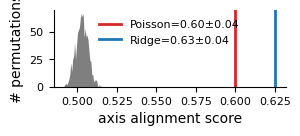

In [46]:
reload(nul)
# plot null distribution
f, ax = plt.subplots(1, 1, figsize=(3, 1))
nul.plot_rotation_null(variance_explained_results, ridge_df, perm_df, print_stats=True, ax=ax)

In [50]:
results_df = lms.load_model_set_cv_scores(
    "other_features", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)

In [13]:
results_df.model_name.unique()

array(['place_direction.distance_to_goal.goal.egocentric_action.velocity',
       'place_direction.distance_to_goal.goal',
       'place_direction.distance_to_goal.goal.egocentric_action.speed',
       'place_direction.distance_to_goal',
       'place_direction.distance_to_goal.head_direction',
       'place_direction.distance_to_goal.goal.egocentric_action',
       'place_direction.distance_to_goal.allocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.allocentric_angle_to_goal.egocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal.egocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal',
       'place_direction.distance_to_goal.egocentric_angle_to_goal.head_direction',
       'place

                                             model_1  \
0                                    place_direction   
1                   place_direction.distance_to_goal   
2              place_direction.distance_to_goal.goal   
3  place_direction.distance_to_goal.goal.egocentr...   
4  place_direction.distance_to_goal.goal.egocentr...   
5  place_direction.distance_to_goal.goal.egocentr...   

                                             model_2     t_stat     p_val  \
0                   place_direction.distance_to_goal   4.293056  0.003883   
1              place_direction.distance_to_goal.goal  -1.910475  0.942842   
2  place_direction.distance_to_goal.goal.egocentr...   7.388154  0.000357   
3  place_direction.distance_to_goal.goal.egocentr...  15.483675  0.000010   
4  place_direction.distance_to_goal.goal.egocentr...   7.665503  0.000301   
5  place_direction.distance_to_goal.goal.egocentr...   3.061159  0.014032   

   p_val_corr  
0    0.005825  
1    0.942842  
2    0.000714  
3  

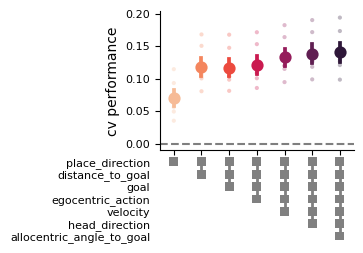

In [ ]:
reload(mc)
f, axes = plt.subplots(2, 1, figsize=(2.5, 3), gridspec_kw={"height_ratios": [4, 2.5], "hspace": 0.05})
mc.plot_other_feature_results(
    results_df,
    models=[
        "place_direction",
        "place_direction.distance_to_goal",
        "place_direction.distance_to_goal.goal",
        "place_direction.distance_to_goal.goal.egocentric_action",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.egocentric_angle_to_goal",
    ],
    plot_single_subjects=True,
    print_stats=True,
    axes=axes,
)
f.savefig(FIG_SAVE_PATH / "other_feature_results.pdf")

subject_ID
m2    87.567199
m3    86.717096
m4    81.043754
m6    83.202209
m7    85.020072
m8    79.046456
dtype: float64
mean ± sem: 83.77 ± 1.35 %


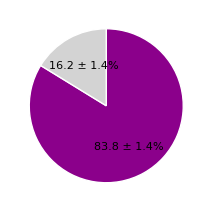

In [15]:
reload(mc)
f, ax = plt.subplots(figsize=(2.5, 2.5))
mc.plot_prop_max_variance_explained(
    results_df,
    small_model="place_direction.distance_to_goal",
    big_model="place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal.egocentric_angle_to_goal",
    colors=("darkmagenta", "lightgrey"),
    outlier_threshold=-0.6,
    print_stats=True,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "prop_max_variance_explained_pi_chart.pdf")

## Supp.

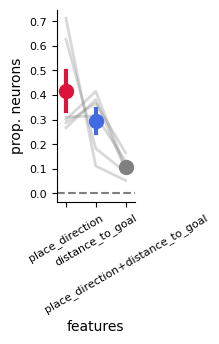

In [16]:
reload(ve)
f, ax = plt.subplots(figsize=(1, 2.5))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=models[::-1],
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "prop_neurons_variance_explained.pdf")

## neGLM hyperparam sweep + step 1 training/loss

In [ ]:
from GridMaze.analysis.neGLM import param_sweep as ps

results_df = ps.load_sweep_results()
training_df = ps.load_sweep_training()

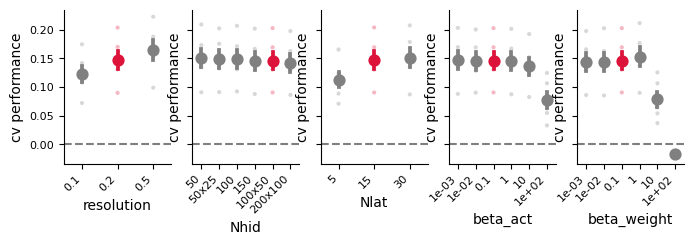

In [21]:
reload(ps)
f, axes = plt.subplots(1, 5, figsize=(8, 2), sharey=True)
ps.plot_hyperparam_sweep_summary(results_df, baseline_color="crimson", axes=axes)
f.savefig(FIG_SAVE_PATH / "hyperparam_sweep_summary.pdf")

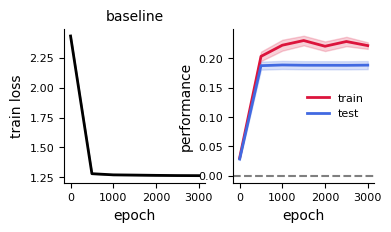

In [23]:
reload(ps)
f, axes = plt.subplots(1, 2, figsize=(4, 2))
ps.plot_training_curves(
    training_df, model_name="baseline", train_color="crimson", test_color="royalblue", loss_color="black", axes=axes
)
f.savefig(FIG_SAVE_PATH / "baseline_training_curves.pdf")